## Learning the grammer of signed regulatory interactions with relation-aware GNNs

During my previous post, I discussed self-supervised edge prediction as a way of embedding the genes in a gene-regulatory network.

This allows genes, metabolites, drugs and other vertices to be connected based on their shared connections however, to date, I've only discussed predicting edges using a dot-product head where a pair's support is direct readout of their similarity in embedding space (\textbf{a} x \textbf{b}). This is a superprisingly powerful head but it is still somewhat limiting especially if there are heterogenous types of vertices or qualitatitvely different ways that they interact.

Here, I'll explore more general approaches for learning mappings between A -> B by evaluating more expressive edge prediction heads (like an MLP) and also applying "relation-aware" heads which can learn distinct mappings for different types of edges.

Edge prediction is a powerful approach for predicting regulatory relationships between molecular species but not all regulatory relations are equivalent. They vary both in how a pair of molecules interact (physical, functional, mechanistic) and in terms of what the consequences of this interaction are (activation, inhibition, ambiguous, inert). This information is partially captured by the edge encoder to capture how likely a message is to be transmitted along edges in the graph during message passing but the ultimate prediction is just whether an edge/interaction exists (yes/no?). Ideally, I'd like these models to be able to predict how an interaction occurs and so I turned to relation-aware approaches. Relations are commonly discussed in the context of graph knowledgebases, where we may have a set of qualitatively different vertex types which can be connected by different types of relationships. For example, we could embed the Open Targets knowledgebase graph to organize genes and phenotypes in a common manifold and could also connect other entity types like drugs, chemical probes, etc. Learning relation-aware edges lets us define connections to map between regions of the embedding.

## Workflow updates supporting relation prediction

### Restructuring the `NapistuGraph` - no more reaction vertices

Earlier versions of Napistu included both molecular species (proteins, metabolites, drugs, etc.) vertices and reaction vertices. For complex regulatory mechanisms, like enzymatic reactions, this anchored pairwise molecular interactions with a clear descrption of their shared function. This was also a handy feature for network visualization because the reactions arising from a common source, particularly the many narrowly-scoped Reactome pathways, were ideal for labeling the pathways associated with different network neighborhoods.

However, the major downside of including reactions in a graph is that individual edges are not meaningful. For example, an enyzme transforming A -> B would be incoded as two separate edges (A -> R, and R -> B). For many purposes this is fine but for edge prediction it adds more noise than signal. For the model to learn what an A -> R -> B reaction represents it would somehow need to capture B's embedding in the R embedding so it would first need to predict a B-informed R. This is a difficult and unnecessary task so for GNNs I'm moving to just predict A -> B connections.

Predicting direct connections does add the wrinkle that I had previously enforced that there was no more than one A -> B connection. Moving to a reaction-less graph, I relaxed this constraint so now multiple edges can connect an A-B pair. This allows activating, inhibitory, interaction, etc. edges to simultaneously exist (when most would have previously been distinguished by reaction vertices).

### Adding `relation_type` to `NapistuData`

When wiring the network graph I encode mechanisms as a series of pairwise interactions based on reaction participants' role in each reaction. The System Biology Ontology (SBO) controlled vocabulary used here (interactor, stimulator, inhibitory, modifier, modified, etc.) is ideal for capturing different types of regulatory mechanisms. To translate this in a `relation_type`s for edges, I combined an edges source and target SBO term into new labels such as (catalyst -> reactant, interactor -> interactor, and stimulator -> modified).

To support relations in `NapistuData` (a subclass of *PyG* `Data`) I added `relation_type` and its association `relation_manager` (for tracking label metadata) as optional attributes. The logistics of creating these relation_types is elegantly handled as an extension of the existing "edge_strata" functionality which was used to organize edges based on vertex and/or species type for the purpose of creating hard negative samples.

## Fitting relation-aware models

During standard edge prediction, we score a possible edge based on the source and target vertices' embeddings. For relation prediction, we also provide heads with a *relation_type* integer which can be used to distinguish different types of relations. To evaluate different head architectures I trained a range of relation-aware heads and some simpler relation-unaware baselines. 

To make it easier to compare different heads using a common encoding framework I trained a 128-dim `GraphConv` message passing encoder with a 32-dim edge encoder to learn edge reliability and a simple dot product head. I then deployed this model to HuggingFace and for each head of interest I loaded the pretrained encoder.

To take advantage of this pretraining I:
- lowered the training rate substantially from 0.003 in the original dot-product head to 0.0005 in the fine-tuned head
- used the one-cycle scheduler to gradually ramp up the learning rate
- created `init_as_identity` initialization settings (when appropriate) so expressive heads started from a similar state as the dot-product head used for pre-training

I fitted all of these models using model-specific configs and the Napistu-Torch CLI.   

## Evaluating relation-aware models

To compare these models, I'll load them from HuggingFace.


In [1]:
# imports
import os
from pathlib import Path
import textwrap

from matplotlib import pyplot as plt
from napistu.ingestion.perturbseq import assign_predicted_direction, load_harmonizome_perturbseq_datasets, _get_distinct_harmonizome_perturbseq_interactions
from napistu.ingestion.constants import SIGNED_PERTURBATION_TYPES, STRONG_ORDERED_SIGNED_PERTURBSEQ_DIRECTIONS
import napistu.utils as napistu_utils
import pandas as pd

from napistu_torch.evaluation.evaluation_manager import EvaluationManager
from napistu_torch.visualization.basic_metrics import plot_auc_only, _extract_metric
from napistu_torch.visualization.advanced_metrics import plot_combined_grouped_barplot
from napistu_torch.evaluation.relation_prediction import (
    calculate_relation_type_confusion_and_correlation,
    compare_relation_type_predictions_to_perturbseq_truth,
    get_perturbseq_edgelist_tensor,
    summarize_relation_type_aucs,
)
from napistu_torch.models.constants import HEAD_DESCRIPTIONS
from napistu_torch.utils.tensor_utils import compute_correlation_matrix, compute_effective_dimensionality
from napistu_torch.visualization.heatmaps import plot_heatmap

# globals
EXPERIMENTS_DIR = Path("/Users/sean/Desktop/EXPERIMENTS/20251211_relation_prediction/")
assert EXPERIMENTS_DIR.is_dir(), f"Path to models does not exist: {EXPERIMENTS_DIR}"

EXPERIMENT_DISPLAY_ORDER = [
    "rotate",
    "dot_product",
    "distmult",
    "transe",
    #"attention",
    #"relation_attention",
    "mlp",
    "relation_gated_mlp",
    "relation_attention_mlp",
]

EXPERIMENTS = {
    "distmult" : "relation_prediction_distmult_128e_transfer_v1",
    "dot_product" : "relation_prediction_dotprod_128e_transfer_v1",
    "mlp" : "relation_prediction_mlp_128e_transfer_v1",
    "relation_attention" : "relation_prediction_relationattention_128e_transfer_v1",
    "relation_attention_mlp" : "relation_prediction_relationattnmlp_128e_transfer_v1",
    "relation_gated_mlp" : "relation_prediction_relationgatedmlp_128e_transfer_v1",
    "rotate" : "relation_prediction_rotate_128e_transfer_v1-2",
    "transe" : "relation_prediction_transe_128e_transfer_v1-2",
}

RELATION_AWARE_FOCUSED_HEADS = ["distmult", "transe", "relation_gated_mlp", "relation_attention_mlp"]

PERTURBSEQ_RELATION_TYPES = ["inhibitor -> modified", "stimulator -> modified"]

# local caches
LOCAL_HARMONIZOME_DATA_DIR = "/tmp/harmonizome_data"
CROSS_RELATION_PREDICTION_CACHE = "/tmp/cross_relation_prediction_matrices.pkl"


/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
eval_managers = dict[str, EvaluationManager]()
for experiment in EXPERIMENT_DISPLAY_ORDER:
    experiment_dir = EXPERIMENTS[experiment]
    experiment_path = EXPERIMENTS_DIR / experiment_dir
    
    if not experiment_path.is_dir():
        print(f"Experiment path does not exist: {experiment_path}")
        continue

    eval_managers[experiment] = EvaluationManager(experiment_path)

ordered_labels = [
    textwrap.fill(HEAD_DESCRIPTIONS[x]["label"], width=20)  # Adjust width as needed
    for x in EXPERIMENT_DISPLAY_ORDER
]

# Extract model summaries directly from Weights & Biases using their API
run_summaries = {exp: manager.get_run_summary() for exp, manager in eval_managers.items()}

# Load all of the trained models
models = {k : v.load_model_from_checkpoint() for k, v in eval_managers.items()}

# Count trainable parameters in each head
n_head_params = {k : sum(p.numel() for p in v.task.head.head.parameters()) for k, v in models.items()}

# connect to the NapistuDataStore and load the NapistuData instance which all models were trained on
# all of the experiments have the same value so we just need to pick an arbitrary one
napistu_data = eval_managers["dot_product"].load_napistu_data()
relation_types = list(napistu_data.relation_manager.label_names.values())

wandb: Currently logged in as: shackett (napistu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.p

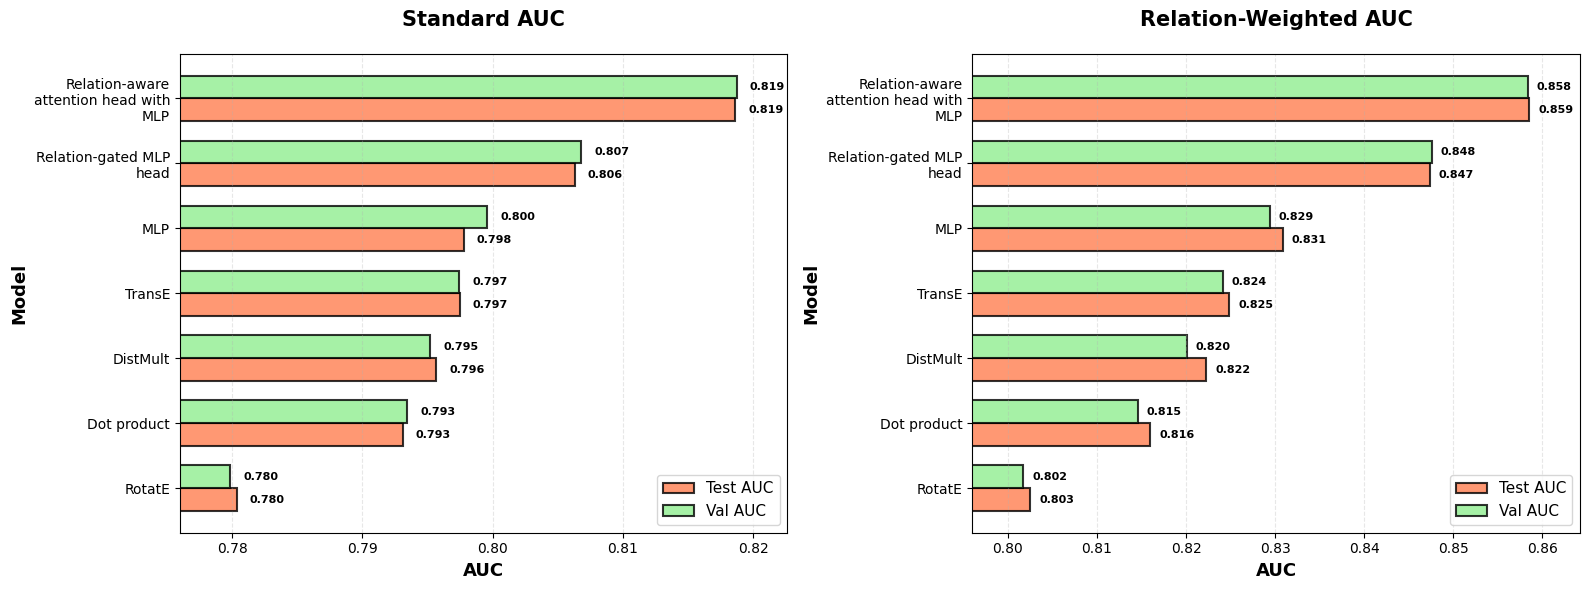

In [3]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot regular AUC on first axis
plot_auc_only(run_summaries, ordered_labels, ax=ax1, title = "Standard AUC")

# Plot relation-weighted AUC on second axis
plot_auc_only(
    run_summaries,
    ordered_labels,
    test_auc_attribute="test_relation_weighted_auc",
    val_auc_attribute="val_relation_weighted_auc",
    title="Relation-Weighted AUC",
    ax=ax2
)

plt.tight_layout()
plt.show()

In [4]:
# create a summary table
# model_summaries = pd.DataFrame([{**HEAD_DESCRIPTIONS[k], "experiment": k} for k in EXPERIMENT_DISPLAY_ORDER])
model_summaries = pd.DataFrame([HEAD_DESCRIPTIONS[k] for k in EXPERIMENT_DISPLAY_ORDER])
model_summaries["category"] = model_summaries["category"].str.replace("_", " ").str.capitalize()
model_summaries["N Parameters"] = [n_head_params[k] for k in EXPERIMENT_DISPLAY_ORDER]
model_summaries["Test RW-AUC"] = _extract_metric(run_summaries, "test_relation_weighted_auc")
model_summaries["Val RW-AUC"] = _extract_metric(run_summaries, "val_relation_weighted_auc")
display(napistu_utils.style_df(model_summaries))


,label,category,description,N Parameters,Test RW-AUC,Val RW-AUC
0,RotatE,Knowledge graph embedding,RotatE: Knowledge Graph Embedding by Relational Rotation in Complex Space,704,0.803,0.802
1,Dot product,Edge prediction,Simple dot product of source and target embeddings,0,0.816,0.815
2,DistMult,Knowledge graph embedding,DistMult: Embedding Entities and Relations for Learning and Inference in Knowledge Bases,1408,0.822,0.820
3,TransE,Knowledge graph embedding,TransE: Translating Embeddings for Modeling Multi-relational Data,1408,0.825,0.824
4,MLP,Edge prediction,"Multi-layer perceptron head that concatenates source and target embeddings, then applies 2-layer MLP with ReLU and dropout.",16513,0.831,0.829
5,Relation-gated MLP head,Relation prediction,"Edge features are processed through MLP, then modulated by relation-specific gates (element-wise multiplication), and passed through output MLP.",25537,0.847,0.848
6,Relation-aware attention head with MLP,Relation prediction,"Processes edge features through MLP, then uses relation embeddings as queries in multi-head attention to select relevant features. Includes residual connection and output MLP for final prediction.",91585,0.859,0.858


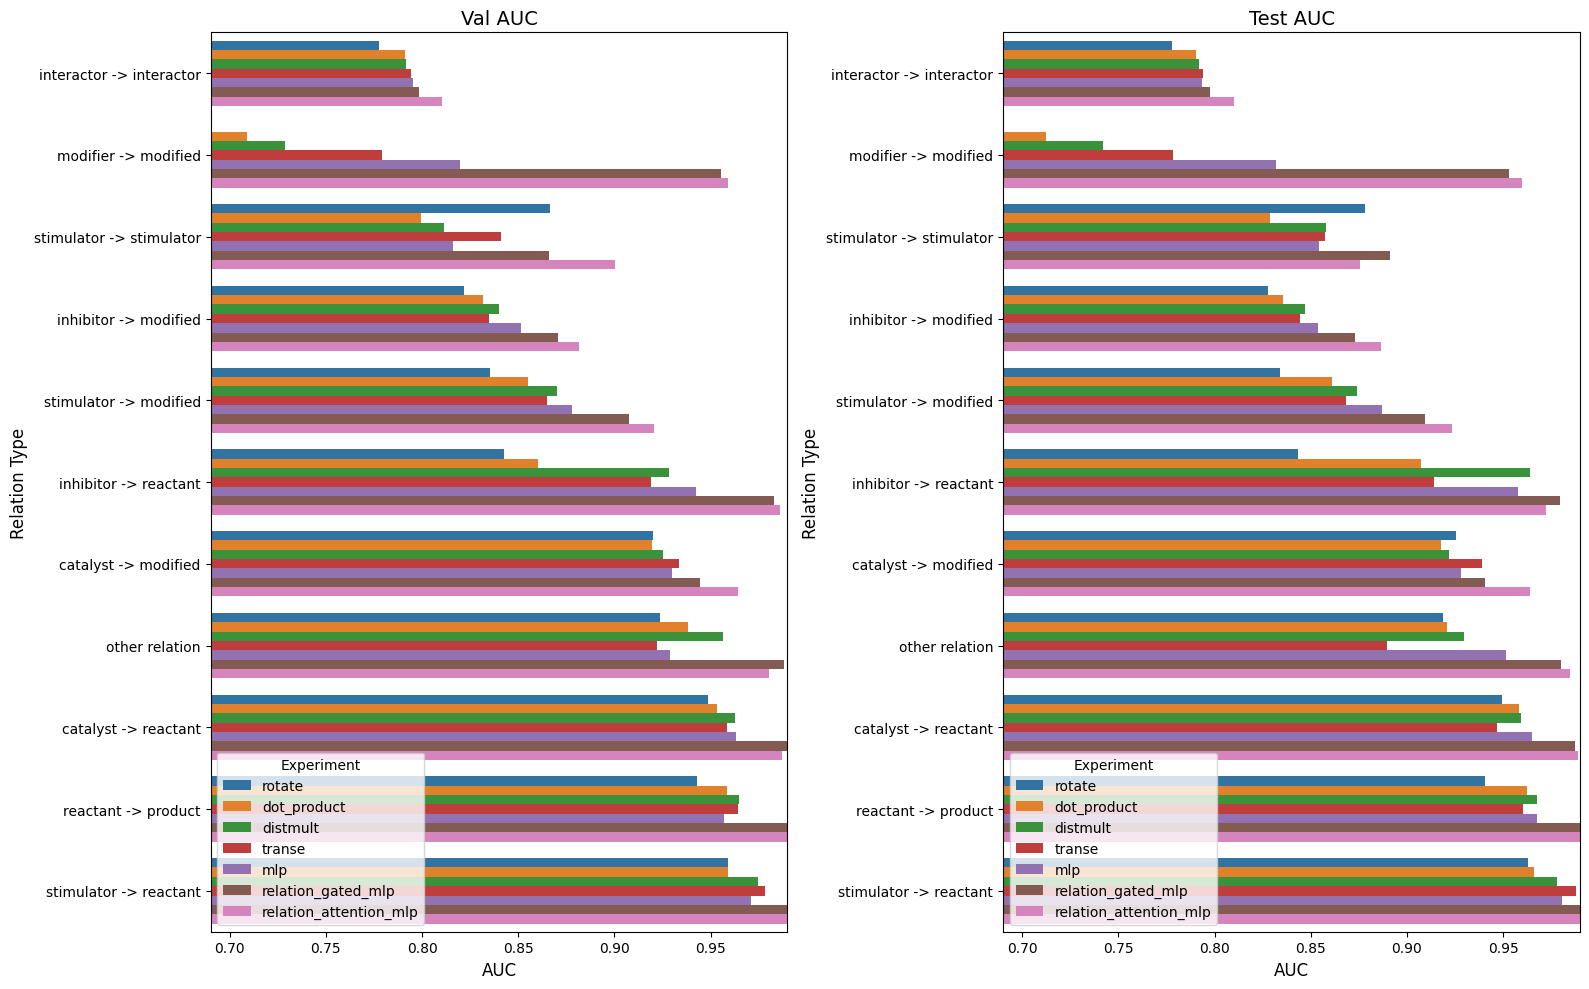

In [5]:
relation_type_aucs = summarize_relation_type_aucs(run_summaries, relation_types)
ordered_experiments = relation_type_aucs.groupby("experiment").sum().sort_values(by="val_auc", ascending=True).index.tolist()
ordered_relation_types = relation_type_aucs.groupby("relation_type").sum().sort_values(by="val_auc", ascending=True).index.tolist()

fig, ax = plot_combined_grouped_barplot(relation_type_aucs, category_order = ordered_relation_types, attribute_order = ordered_experiments)
plt.show()

## Evaluating relation-aware models

Having selected top-contending relation-aware models I want to now explore whether they are making meaningful signed regulatory predictions. I'll do this using three analyses:

1. Using interpretable relation-aware heads I'll explore geometric representation of activation and inhibition. 
2. For top-performing heads I'll explore the strength of regulatory predictions - are scores similar regardless of the putative relation-type, or are models confidently predicting relation-type.
3. Leveraging PerturbSeq data, I'll model's signed regulatory predictions.

### What is the geometry of activation and inhibition?

To see if relation-aware heads are learning meaningful regulatory semantics I'll explore two heads more deeply:

- RotatE splits the vertex embedding (128 dims) into 64 pairs and treats each pair as relation-specific real and imaginary components of a complex rotation. In this way it learns relation-specific rotations that map the source vertex onto the target vertex. A big caveate in interpreting the results from RotatE is that it doesn't actually outperform a simple dot-product head. This may be because it removes some of the expressivity from the vertex embedding by treating it as a 64-dimensional complex embedding.
- TransE defines relation-specific translations as vectors which translate the source vertex onto the target vertex.

A couple of hypotheses I had going into this analysis were:

1. interactor edges should have minimal rotations and small vectors since they are symmetric. For $A + r - B$ and $B + r - A$ to both be small $r$ should be small.
2. activation and inhibition should partially opose one another - $r_{\text{activator}} - r_{\text{modifier}} \approx -1*r_{\text{inhibitor}} - r_{\text{modifier}}$

Since RotatE rotations and TransE translations are directly estimated as weights in the relation-embedding, I'll extract these and explore relation-type's transformations.

In [6]:
RotatE_manager = eval_managers["rotate"]
RotatE_head = RotatE_manager.load_model_from_checkpoint().task.head.head
# relation embedding are the real and complex rotation angles in radians
RotatE_phases = RotatE_head.relation_emb.weight.detach().cpu()

TransE_manager = eval_managers["transe"]
TransE_model = TransE_manager.load_model_from_checkpoint()
TransE_head = TransE_model.task.head.head
TransE_vectors = TransE_head.relation_emb.weight.detach().cpu()


To summarize the RotatE rotations and TransE vectors, I'll create three summaries:

1. Total phase: The L1 norm of RotatE relation_type rotations across all embedding dimensions
2. Total translation: The L1 norm of TransE vectors across all embedding dimensions
3. Effective translation dimension: The # of embedding components over which the TransE signal is distributed

In [7]:
geometry_summaries = pd.DataFrame({
    "relation_type" : relation_types,
    "total_phase" : RotatE_phases.abs().sum(dim=1).numpy(),
    "total_translation" : TransE_vectors.abs().sum(dim=1).numpy(),
    "effective_translation_dim" : compute_effective_dimensionality(TransE_vectors)

}).sort_values(by="total_phase", ascending=False)

display(napistu_utils.style_df(geometry_summaries))

,relation_type,total_phase,total_translation,effective_translation_dim
5,modifier -> modified,20.157,6.841,80.751
2,inhibitor -> modified,9.150,6.366,49.534
9,stimulator -> reactant,6.902,6.049,19.917
3,inhibitor -> reactant,6.886,4.182,47.928
1,catalyst -> reactant,5.979,5.715,36.132
0,catalyst -> modified,4.550,6.129,42.156
8,stimulator -> modified,3.853,7.433,79.989
10,stimulator -> stimulator,3.434,5.630,42.252
7,reactant -> product,2.619,6.403,48.338
6,other relation,2.036,5.319,51.076


As I initially hypothesized interactor -> interactor relation_types result in a minimal rotation. In contrast, TransE translations for interactors have a suprisingly large magnitude (6.7). While, I was suprised by this because it implies that $A + r - B \neq B + r - A$, this relation is not directly required. The source + r - target distances generates an edge score (-distance) and the actual loss and evaluation measures are calculated based on the differences of loss between real and negatively sampled edges. So, the model may be learning relation translations across dimensions which improve discrimination of real and negative edges. This is partially supported by the high effective dimension of the "interactor -> interactor" relation-type used for discriminative signal in contrast to the small number of semantic meaningful dimensions used for relation-types like "stimulator -> reactant" and "catalyst -> reactant".

With the caveate that TransE vectors are capturing discriminative signals which may not be semantically meaningful we can still search for such signals by comparing relation-type's translation vectors.

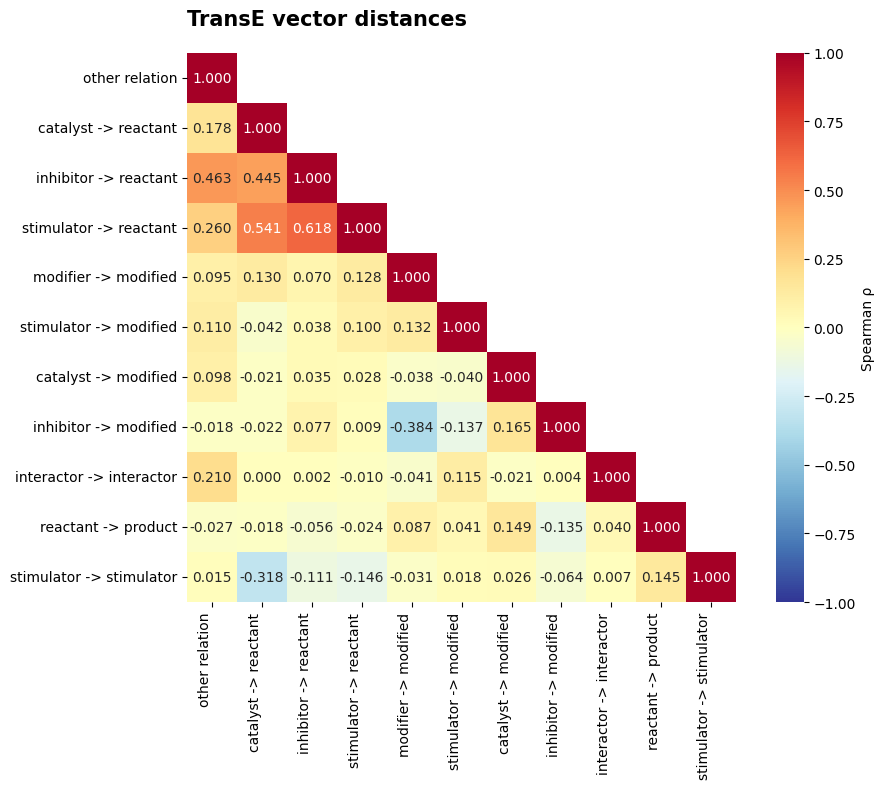

In [8]:
corr_matrix, _ = compute_correlation_matrix(TransE_vectors.T)

_ = plot_heatmap(
    corr_matrix,
    row_labels=relation_types,
    title='TransE vector distances',
    cmap='RdYlBu_r',
    fmt='.3f',
    vmin=-1,
    vmax=1,
    center=0,
    cbar_label='Spearman ρ',
    mask_upper_triangle=True,
    square=True,
    cluster='both',
    cluster_method='average',
    cluster_metric='correlation'
)

This heatmap has two prominent features:

1. Relation-types ending in "reactant" result in similar vectors. This is likely because catalysts, inhibitors and stimulators are primarily genes/proteins while reactants are generally metabolites. The systematic transition reflects proteins and metabolites occupying different regions of the embedding. Creating meaningful links between qualitatively different types of vertices is exactly what knowledgegraph embedding methods like TransE aims for.
2. The inhibitor -> modified vector is anticorrelated with the modifier/stimulator -> modified vector. This suggests that as initially hypothesized there is some separation of activators and inhibitors in embedding space resulting in partially opposing translation vectors.

### Are models scoring specific relation_types strongly or providing similar scores irrespective of relation_type?

If heads are learning relation-type specific transformations then I'd expect edges will score highly for some relation-types and poorly for others, while if heads are leaning primarily on the vertex embeddings themselves then high- and low-confidence edges should score similarly regardless of the relation-type.

To evaluate the specificity of relation-type-based scoring, I'll take each edge in the test set and score it for every relation-type.

Then i'll create a relation-type by relation-type simlarity based on the Spearman correlation of the relation-types' edge scores.

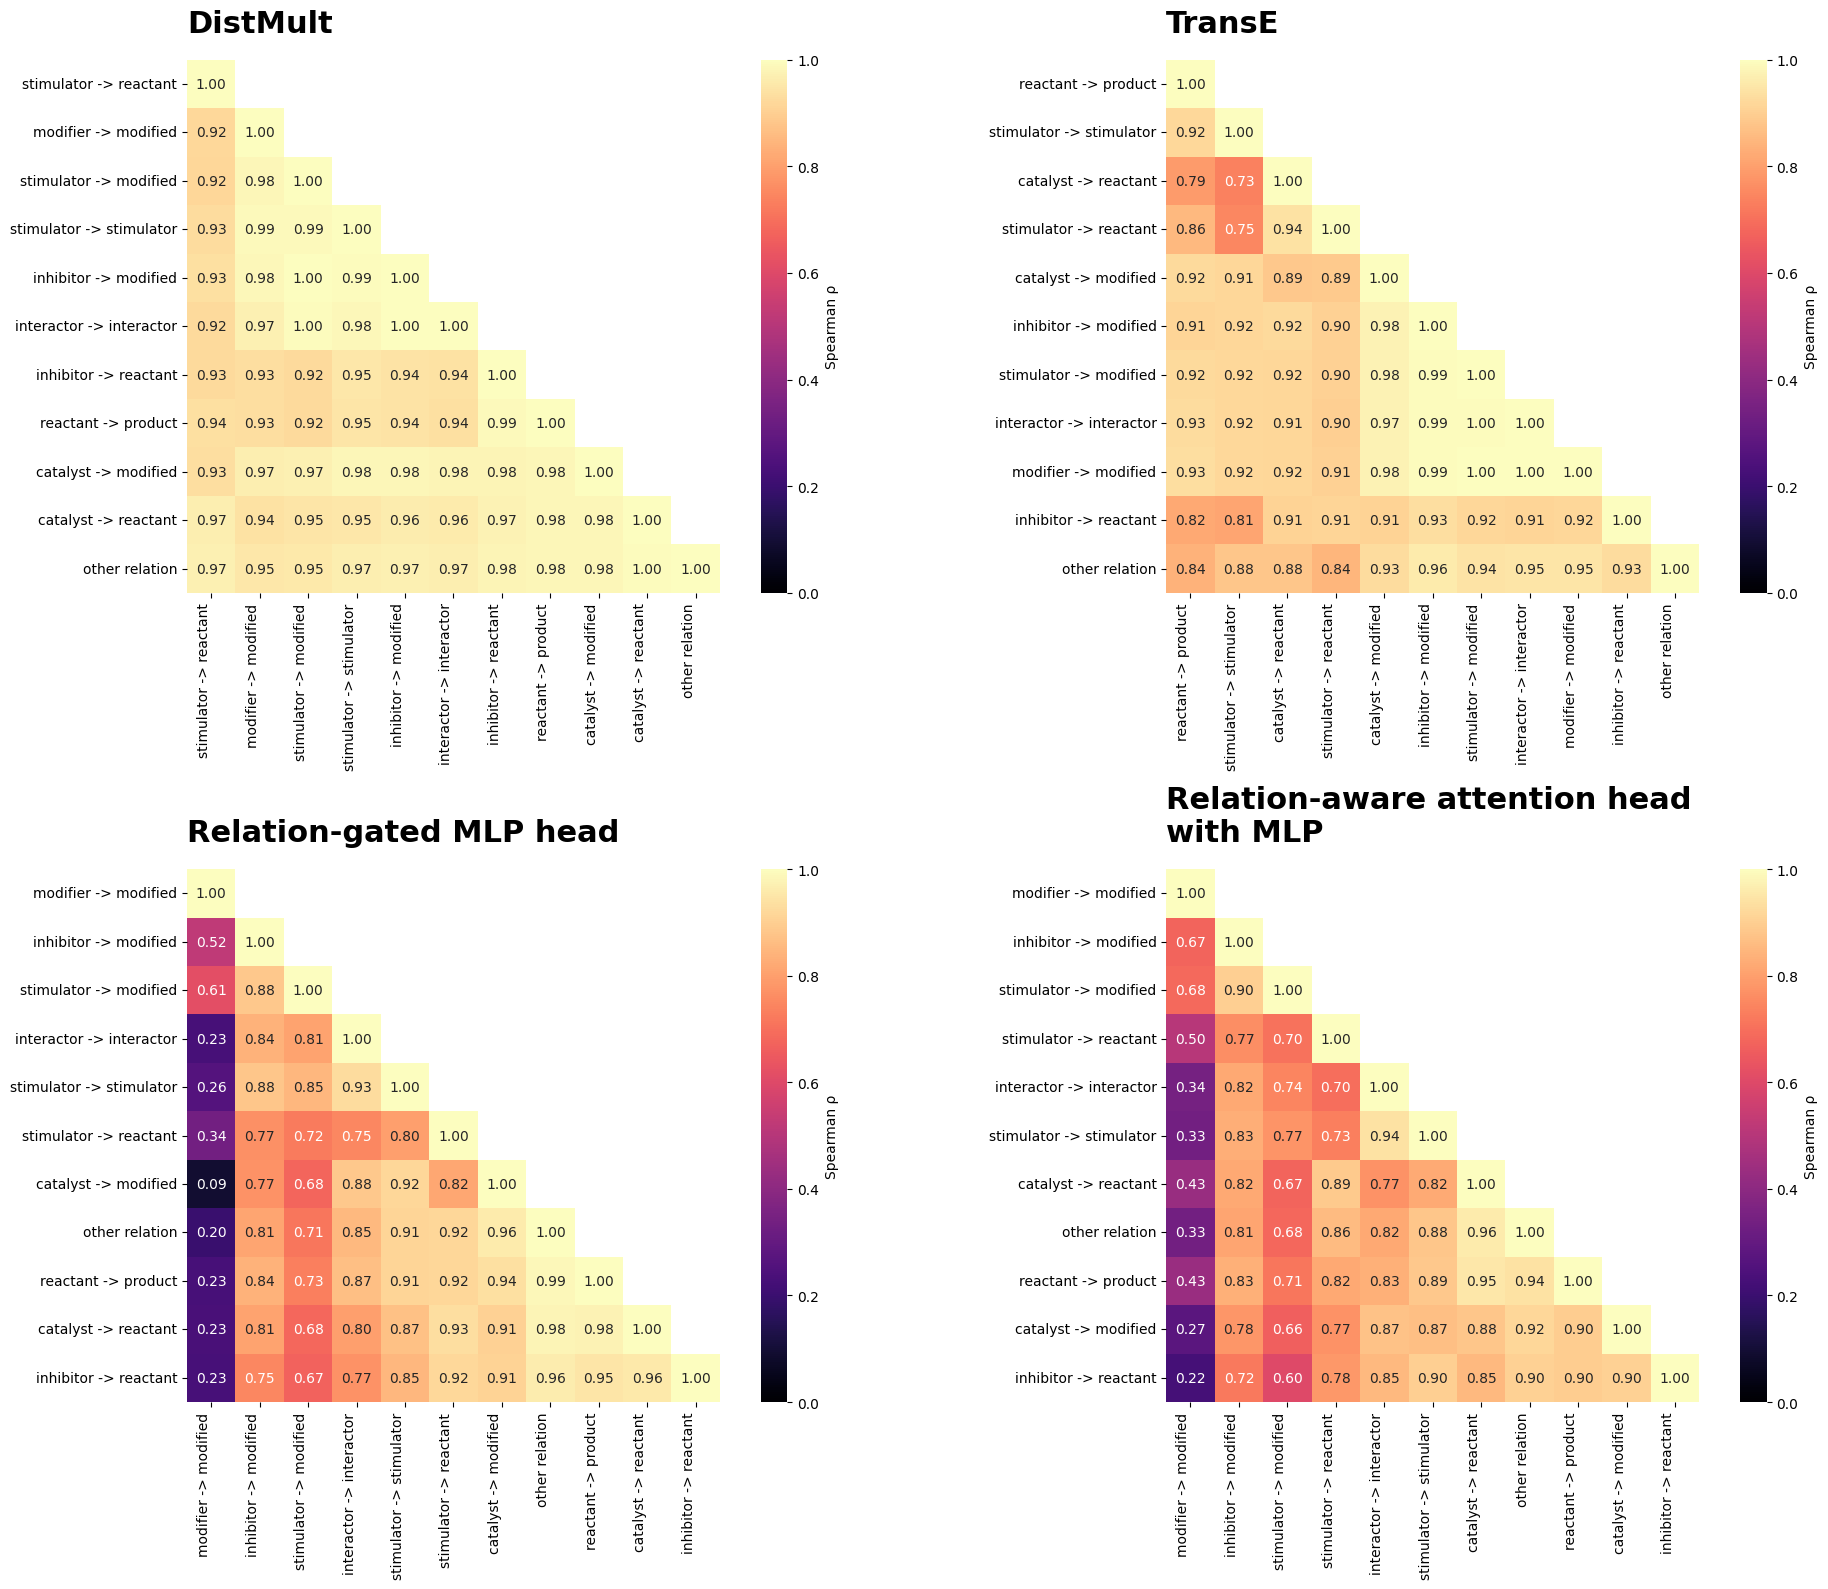

In [9]:
if not os.path.exists(CROSS_RELATION_PREDICTION_CACHE):
    cross_relation_prediction_matrices = {"confusion": {}, "correlation": {}}
    for experiment in RELATION_AWARE_FOCUSED_HEADS:
        manager = eval_managers[experiment]
        model = manager.load_model_from_checkpoint()
        cross_relation_prediction_matrices["confusion"][experiment], cross_relation_prediction_matrices["correlation"][experiment] = (
            calculate_relation_type_confusion_and_correlation(model, napistu_data, normalize="true")
        )

    napistu_utils.save_pickle(CROSS_RELATION_PREDICTION_CACHE, cross_relation_prediction_matrices)
else:
    cross_relation_prediction_matrices = napistu_utils.load_pickle(CROSS_RELATION_PREDICTION_CACHE)

# In subplots (new behavior)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, head in enumerate(RELATION_AWARE_FOCUSED_HEADS):
    correlation_matrix = cross_relation_prediction_matrices["correlation"][head]
    title = textwrap.fill(HEAD_DESCRIPTIONS[head]["label"], width=30)
    plot_heatmap(
        correlation_matrix,
        row_labels=relation_types,
        title=title,
        cmap='magma',
        fmt='.2f',
        vmax=1,
        vmin=0,
        cbar_label='Spearman ρ',
        mask_upper_triangle=True,
        square=True,
        cluster='both',
        cluster_method='average',
        cluster_metric='euclidean',
        title_size=22,
        ax=axes[idx],
    )

plt.tight_layout()
plt.show()

From these visualizations of cross-relation-type score similarity, I can make a few observations:

1. Expressive relation-aware heads, like the relation-gated MLP head and relation-aware attention head, generate predictions which are highly dependent on relation-type.
2. Knowledgegraph embedding methods, like TransE and DistMult, tend to score edges strongly or weakly irrespective of relation-type. Still, there is structure in their relation-type similarities. In particular, interactor-style edges (interactor -> interactor and * -> modified) tend to score similarly.

The strong correlations of "* -> modified" edges in TransE is somewhat at odds with the signals of activation-inhibition opposition from the previous direct analysis relation-type vector similarities. We can reconcile these observations by appreciating that TransE is likely leaning far more on the source and target vertex embedding's similarities (possibly pulling in some relation-agnostic discriminative signal) than by capturing the nuanced biological semantics of regulation.

These limitations of knowledgegraph embedding methods are not surprising since these methods were created to embed heterogeneous vertices in a common embedding (like molecules, diseases, drugs, etc.) while the graph we're using here is relatively homogeneous (its all molecules even if there are different types of molecular species). In the context of a heterogenous graph certain relation-types may exist strictly between subsets of vertyices (like drug-target interactions, and drug-disease indications) which means that different types of vertices can be strictly separated in the embedding, and relation-types can still serve as learned mappings to connect them. When learning regulatory relation-types the situation is necessarily messier; many molecules can serve as both activators and inhibitors and will possess both regulatory, physicial nad functional interactions.

By generating edge predictions which are highly dependent on relation-type the expressive relation-type-dependent attention and MLP heads show promise in disentangling the multiple roles that molecules can fill. These heads perform great for edge prediction, but if we're interested in predicting novel interactions its important to compare predictions to orthogonal data sources.

### Ground-truth activation and inhibition with PerturbSeq

To explore whether relation-aware edge prediction heads can predict not just whether an interaction exists but how likely it is to be activating or inhibiting, I wanted to pull in additional datasets where molecular species have been specifically perturbed and the directed impact on other molecular species' levels/activities are measured. There are many experiments of this form (e.g., dosing drugs with clear MoA, purifiying enzymes and testing allosteric regulators) but most of these experiments are already baked into the Octopus models data sources or a are not high-throughput enough to generate a substantial validation dataset.

PerturbSeq datasets where a gene is perturbed using CRISPR and then its transcriptome-wide impacts are read-out check the desired boxes for validation since there are a few large datasets where many genes have been perturbed (Replogle et al. (2022), Cell) and many smaller studies investigating more targeted hypotheses (e.g., knocking-in human mutations). The original Replogle datasets doesn't report predicted fold-changes, just Anderson-Darling q-values, so I turned to public resources which have reanalyzed this and other datasets. After evaluating a few such resources, I decided to use Harmonizome, an ongoing effort from the Ma'ayan at Mount Sinai aiming to generate and compare diverse gene-profiles (Diamant, et. al. (2025), Nucleic Acids Resarch). Harmonizome provides signed PerturbSeq fold-changes based on both the Replogle datasets and PerturbAtlas using relatively consistent data formats.

To make use of profiles, I did the following:

1. load species_identifiers (systematic identifier to molecular species id mappings) and species ids -> comaprtmentalized species id maps.
2. load and format Harmonizome-derived PerturbSeq interactions so they are:
    - source and target vertex ids (using the adapters from 1.)
    - select strong perturbations by comparing the Harmonizome value to its threshold
    - infer activation vs. inhibition from the type of perturbation and fold-change direction
        - overexpression and up -> activation
        - overexpression and down -> inhibition
        - knockout/knockdown and up -> repression (i.e., de-repression)
        - knockout/knockdown and down -> activation
        - other perturbation types such as knock-ins are ignored
3. for each PerturbSeq edge (a Tensor of source-target integer positions) I scored edges for repressive (inhibitor -> modified) and activating (stimulator -> modifier) interactions for each model of interest. Then, I assigned the predicted relation_type as the maximum edge.
4. To compare the PerturbSeq predictions (activation vs. repression) and top-scoring relation-types I generated a 2x2 contingency table, summarized significance using a $\chi^{2}$-test and reported the fraction of top scoring activating and inhibiting relation-types for each PerturbSeq strata.


In [10]:
# prepare Napistu adapters for the PerturbSeq data

napistu_data_store = eval_managers["dot_product"].napistu_data_store
# create the species_identifiers and name_to_sid_map artifacts if they don't exist
napistu_data_store.ensure_artifacts(["species_identifiers", "name_to_sid_map"])
species_identifiers = napistu_data_store.load_pandas_df("species_identifiers")
name_to_sid_map = napistu_data_store.load_pandas_df("name_to_sid_map").reset_index()
name_to_sid_map["integer_id"] = range(len(name_to_sid_map))

if not all(name_to_sid_map["name"] == napistu_data.ng_vertex_names):
    raise ValueError("name_to_sid_map does not match napistu_data.ng_vertex_names")

# map relation_types to relation_type indices so we can just score select relation_types
relation_type_indices = {k : i for i, k in enumerate(relation_types)}
focused_relation_type_indices = {k : relation_type_indices[k] for k in PERTURBSEQ_RELATION_TYPES}

# load PerturbSeq results from Harmonizome, map to vertices, and  and filter to strong inhibition and activation
distinct_harmonizome_perturbseq_interactions = (
    load_harmonizome_perturbseq_datasets(LOCAL_HARMONIZOME_DATA_DIR, species_identifiers)
    # rollup to 1 entry per dataset, source, target, and perturbation type
    .pipe(_get_distinct_harmonizome_perturbseq_interactions)
    # filter to only perturbation types where predicted direction is clear (e.g., ignore knock-ins and mutations)
    .query("perturbation_type in @SIGNED_PERTURBATION_TYPES")
    # assign predicted direction (strong inhibition, strong activation)
    .assign(perturbseq_prediction=lambda df: assign_predicted_direction(df))
    .query("perturbseq_prediction in @STRONG_ORDERED_SIGNED_PERTURBSEQ_DIRECTIONS")
)

# pull out all unique from-to species id pairs
distinct_perturbseq_pairs = (
    distinct_harmonizome_perturbseq_interactions[["perturbed_species_id", "target_species_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Map from species_id to integer_ids and convert to tensor
perturbseq_edgelist_tensor = get_perturbseq_edgelist_tensor(
    distinct_perturbseq_pairs,
    name_to_sid_map
)


# create predictions for the models of interest
predicted_relation_type_vs_perturbseq_truth_predictions = {}
predicted_relation_type_vs_perturbseq_truth_pvalues = {}
for experiment in RELATION_AWARE_FOCUSED_HEADS:
    
    model = eval_managers[experiment].load_model_from_checkpoint()

    summaries = compare_relation_type_predictions_to_perturbseq_truth(
        model,
        focused_relation_type_indices,
        perturbseq_edgelist_tensor,
        napistu_data,
        distinct_perturbseq_pairs,
        distinct_harmonizome_perturbseq_interactions,
        STRONG_ORDERED_SIGNED_PERTURBSEQ_DIRECTIONS,
        PERTURBSEQ_RELATION_TYPES,
    )

    predicted_relation_type_vs_perturbseq_truth_predictions[experiment], predicted_relation_type_vs_perturbseq_truth_pvalues[experiment] = summaries

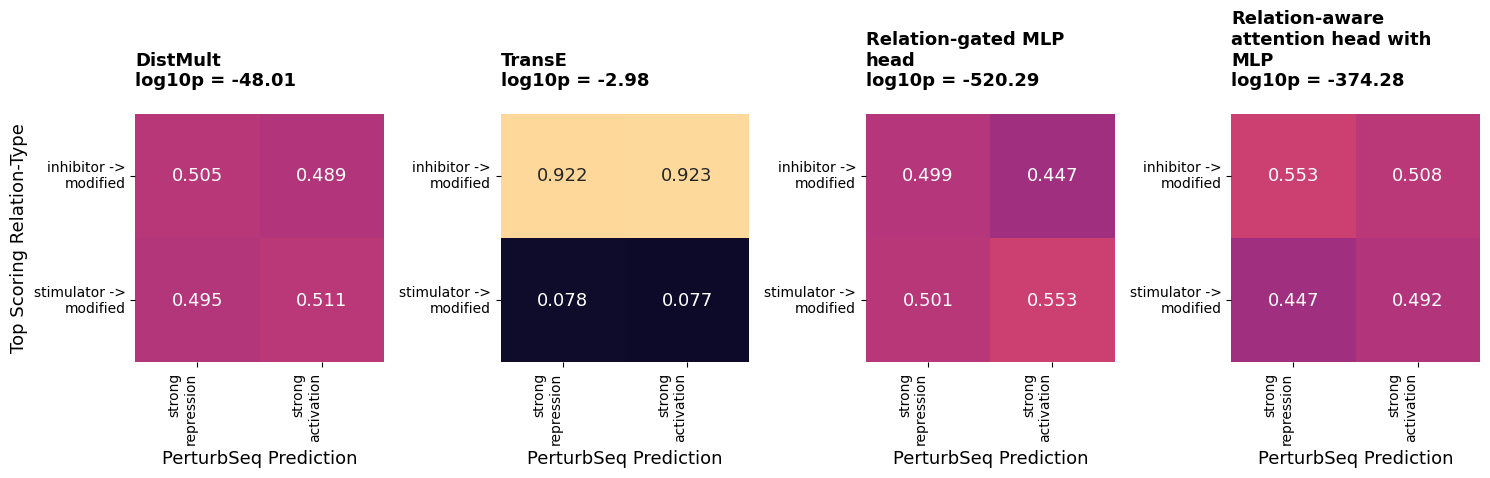

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 7))
axes = axes.flatten()

for idx, head in enumerate(RELATION_AWARE_FOCUSED_HEADS):
    
    dat = predicted_relation_type_vs_perturbseq_truth_predictions[head]
    title = textwrap.fill(HEAD_DESCRIPTIONS[head]["label"], width=20) + "\n" + f"log10p = {predicted_relation_type_vs_perturbseq_truth_pvalues[head].round(2)}"
    row_labels = [textwrap.fill(x, width=20) for x in PERTURBSEQ_RELATION_TYPES]
    col_labels = [textwrap.fill(x, width=10) for x in STRONG_ORDERED_SIGNED_PERTURBSEQ_DIRECTIONS]
    y_label = "Top Scoring Relation-Type" if idx == 0 else None
    
    plot_heatmap(
        dat,
        row_labels=row_labels,
        column_labels=col_labels,
        title=title,
        xlabel="PerturbSeq Prediction",
        ylabel=y_label,
        cmap='magma',
        fmt='.3f',
        vmin=0.0,
        vmax=1,
        cbar_label='Proportion',
        square=True,
        cbar = False,
        title_size=13,
        label_size=13,
        axis_title_size=10,
        annot_size=13,
        ax=axes[idx],
    )

plt.tight_layout()
plt.show()


I can make a few observations about these contingency tables;

- Relation-type's average values can vary substantially. This is most apparent for TransE where inhibitory edges score systematically higher than activating edges resulting in primarily inhibitory top-scoring relation-types. Since the actual loss and evaluation measures are calculating by comparing true and negatively sampled edges within the same strata (which for these models is the same as the relation-types) there is little incentive to calibrate scores across relation-types.
- TransE's top scoring activating and inhibiting edges are independent of the CRISPR ground truth. There is actually a slight excess of counts in the top-right and bottom-left quadrants which are the boxes where relation-type predictions disagree with CRISPR ground truth.
- For the remaining models, the results look REALLY good - there are enrichment of predictions in the top left and bottom right quadrants resulting in outlandish statistical significance and meaningful by-eye enrichments.

The fact that top-scoring edges for activation and inhibition tend to agree with CRISPR ground truth is impressive because there are caveats that hold-back these CRISPR summaries as a source of ground truth:

- Harmonizome predicted calls do not greatly align with the Anderson-Darling significance reported in the Replogle supplement. I was surprised by the limited availability of PerturbSeq summaries which may be due to how subtle the signals are in the datasets. (Its not a great sign when you need to search for significance with the KS-test like Anderson-Darling test.)
- CRISPRi perturbations include both direct and indirect interactions when I'd expect strong predictions for direct interactions but not indirect interactions (though training on a mixture of interaction types may mean that my intuition is off).
- Activation (stimulator -> modifier) and repressive (inhibition -> modifier) edges are relatively rare compared to undirected interactions in the dataset so its impressive that these concepts can 
